In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('HW1_var_3.csv', sep=';').drop(["Номер варианта"], axis=1)
print(df.shape[0])
df.head()

10243


,ID,INCOME_BASE_TYPE,CREDIT_PURPOSE,INSURANCE_FLAG,DTI,SEX,FULL_AGE_CHILD_NUMBER,DEPENDANT_NUMBER,EDUCATION,EMPL_TYPE,...,own_closed,min_MnthAfterLoan,max_MnthAfterLoan,dlq_exist,thirty_in_a_year,sixty_in_a_year,ninety_in_a_year,thirty_vintage,sixty_vintage,ninety_vintage
0,1000003,Поступление зарплаты на счет,Ремонт,0,0.50,мужской,0,0,высшее,специалист,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1000023,2НДФЛ,Ремонт,0,0.54,женский,0,0,высшее,специалист,...,2.0,9.0,94.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
2,1000043,Свободная форма с печатью работодателя,Ремонт,1,0.57,мужской,2,0,высшее,менеджер среднего звена,...,1.0,18.0,18.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1000063,Форма банка (без печати работодателя),Покупка автомобиля,0,0.56,женский,2,0,высшее,специалист,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1000083,Поступление зарплаты на счет,Ремонт,1,0.35,мужской,1,0,среднее,рабочий,...,1.0,24.0,106.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


# Задание №1

### Оставляем только клиентов нашего банка

In [2]:
df[df["BANKACCOUNT_FLAG"] >= 1.0]["BANKACCOUNT_FLAG"] = 1.0
df = df[df["BANKACCOUNT_FLAG"] == 1.0]

print(df["BANKACCOUNT_FLAG"].value_counts(dropna=False))

BANKACCOUNT_FLAG
1.0    1037
Name: count, dtype: int64


### Исследуем заполненность данных

In [3]:
def quality_report(df):
    report = pd.DataFrame({
        'total': len(df),
        'unique': df.nunique(),
        'missing': df.isnull().sum(),
        'zeros': (df == 0).sum(),
        'miss_pct': (df.isnull().sum() / df.shape[0] * 100).round(2),
        'zero_pct': ((df == 0).sum() / df.shape[0] * 100).round(2),
        'dtype': df.dtypes.astype(str)
    })
    return report.sort_values('miss_pct', ascending=False)

quality = quality_report(df)
display(quality)

,total,unique,missing,zeros,miss_pct,zero_pct,dtype
avg_num_delay,1037,213,616,180,59.40,17.36,float64
ninety_vintage,1037,2,613,417,59.11,40.21,float64
Active_not_cc,1037,6,613,101,59.11,9.74,float64
num_AccountActive180,1037,6,613,261,59.11,25.17,float64
num_AccountActive90,1037,5,613,339,59.11,32.69,float64
num_AccountActive60,1037,4,613,364,59.11,35.10,float64
Active_to_All_prc,1037,44,613,35,59.11,3.38,float64
numAccountActiveAll,1037,9,613,33,59.11,3.18,float64
numAccountClosed,1037,18,613,38,59.11,3.66,float64
sum_of_paym_months,1037,168,613,3,59.11,0.29,float64


### Переведем категориальные переменные в числовые

Сделаем это с помощью one_hot_encoding

In [4]:
cat_cols = df.select_dtypes(include=['object']).columns

df_dummies = pd.get_dummies(df[cat_cols], prefix=cat_cols, prefix_sep='_', dummy_na=False)
df_clean_enhanced = pd.concat([df, df_dummies], axis=1).drop(cat_cols, axis=1)

In [5]:
df[cat_cols[0]]

0        Поступление зарплаты на счет
9        Поступление зарплаты на счет
16       Поступление зарплаты на счет
27       Поступление зарплаты на счет
34       Поступление зарплаты на счет
                     ...             
10122                           2НДФЛ
10124                           2НДФЛ
10189                           2НДФЛ
10201                           2НДФЛ
10215    Поступление зарплаты на счет
Name: INCOME_BASE_TYPE, Length: 1037, dtype: object

### Посмотрим на распределение категориальных переменных

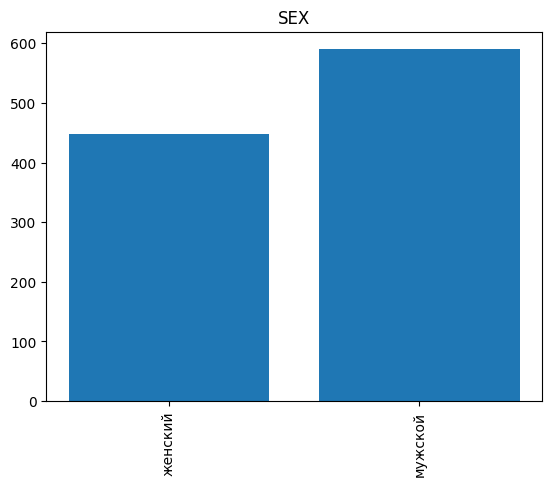

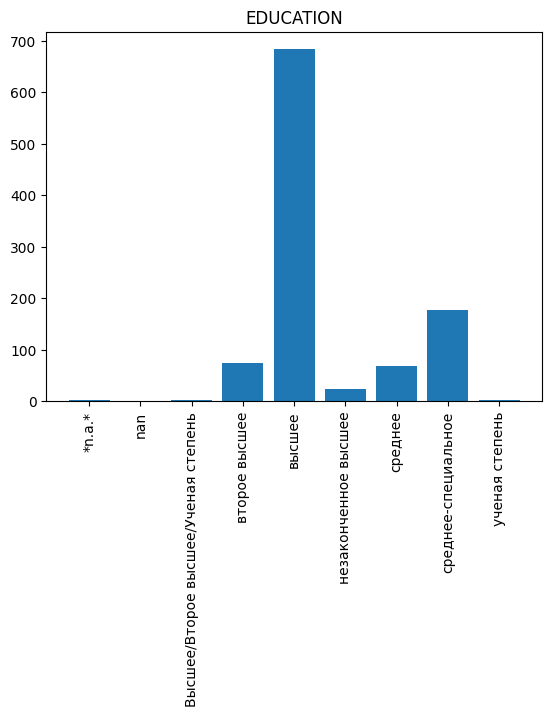

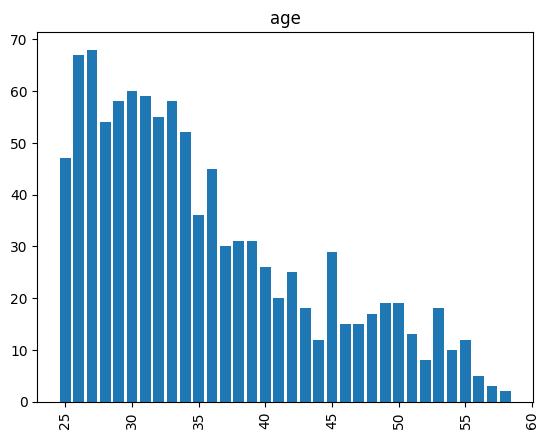

In [6]:
for col in ["SEX", "EDUCATION", "age"]:
    keys, counts = np.unique(df[col].to_list(), return_counts=True)

    plt.title(col)
    plt.bar(keys, counts)
    plt.xticks(rotation=90)
    plt.show()

### Заполним nan'ы дефолтным значением (-1). 

Так мы 
1) Не будем выкидывать клиентов (их и так мало)
2) Дадим модели какой-то сигнал что с этим делать (вдруг 0 это другое значение)
3) У нас всего 1000 клиентов банка, а у большой части колонок NaN >= 60%.

In [7]:
df_clean_enhanced = df_clean_enhanced.fillna(-1)

df_clean_enhanced[df_clean_enhanced.isna()].count()

ID                                    0
INSURANCE_FLAG                        0
DTI                                   0
FULL_AGE_CHILD_NUMBER                 0
DEPENDANT_NUMBER                      0
                                     ..
FAMILY_STATUS_гражданский брак        0
FAMILY_STATUS_женат / замужем         0
FAMILY_STATUS_повторный брак          0
FAMILY_STATUS_разведен / разведена    0
FAMILY_STATUS_холост / не замужем     0
Length: 90, dtype: int64

### Посмотрим статистику переменных

In [8]:
num_stats = df_clean_enhanced.describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]).round(2)
num_stats['unique'] = df_clean_enhanced.nunique()
num_stats['missing_pct'] = (df_clean_enhanced.isnull().sum() / len(df) * 100).round(2)
display(num_stats)

,ID,INSURANCE_FLAG,DTI,FULL_AGE_CHILD_NUMBER,DEPENDANT_NUMBER,BANKACCOUNT_FLAG,Period_at_work,age,max90days,max60days,...,max_MnthAfterLoan,dlq_exist,thirty_in_a_year,sixty_in_a_year,ninety_in_a_year,thirty_vintage,sixty_vintage,ninety_vintage,unique,missing_pct
count,1037.00,1037.00,1037.00,1037.00,1037.00,1037.0,1037.00,1037.00,1037.00,1037.00,...,1037.00,1037.00,1037.00,1037.00,1037.00,1037.00,1037.00,1037.00,NaN,NaN
mean,1091449.11,0.55,0.31,0.59,0.01,1.0,67.83,35.49,0.11,-0.11,...,23.99,-0.36,-0.54,-0.56,-0.57,-0.58,-0.58,-0.58,NaN,NaN
std,55265.50,0.50,0.40,0.78,0.09,0.0,65.76,8.23,1.75,1.39,...,35.65,0.83,0.60,0.55,0.54,0.52,0.51,0.51,NaN,NaN
min,1000003.00,0.00,-1.00,0.00,0.00,1.0,6.00,25.00,-1.00,-1.00,...,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00,NaN,NaN
1%,1001946.20,0.00,-1.00,0.00,0.00,1.0,6.00,25.00,-1.00,-1.00,...,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00,NaN,NaN
25%,1044963.00,0.00,0.30,0.00,0.00,1.0,23.00,29.00,-1.00,-1.00,...,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00,NaN,NaN
50%,1091903.00,1.00,0.41,0.00,0.00,1.0,48.00,33.00,-1.00,-1.00,...,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00,NaN,NaN
75%,1130263.00,1.00,0.52,1.00,0.00,1.0,89.00,41.00,1.00,0.00,...,52.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,NaN,NaN
99%,1200245.40,1.00,0.59,3.00,0.00,1.0,343.20,55.00,7.00,5.00,...,106.00,1.00,1.00,1.00,1.00,1.00,0.00,0.00,NaN,NaN
max,1204303.00,1.00,0.59,4.00,2.00,1.0,457.00,58.00,13.00,9.00,...,135.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,NaN,NaN


# Задание №3

Сначала задание №3, чтобы определить кол-во кластеров \
Затем задание №2

In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns


scaler = StandardScaler()

df_scaled = pd.DataFrame(
    scaler.fit_transform(df_clean_enhanced.drop(["ID", "BANKACCOUNT_FLAG"], axis=1)), # Выкидываем бесполезные колонки
    index=df_clean_enhanced.index
)
X = df_scaled

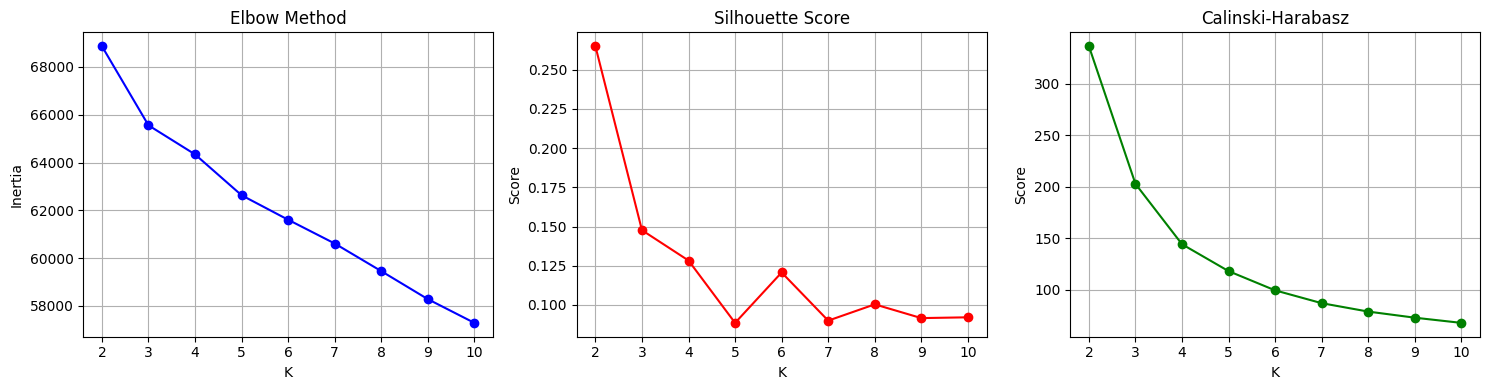

In [10]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score
import matplotlib.pyplot as plt
import pandas as pd

k_range = range(2, 11)
inertia, silhouette, calinski = [], [], []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=41, n_init=10)
    labels = kmeans.fit_predict(X)
    
    inertia.append(kmeans.inertia_)
    silhouette.append(silhouette_score(X, labels))
    calinski.append(calinski_harabasz_score(X, labels))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(k_range, inertia, 'bo-')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Inertia')
axes[0].grid(True)

axes[1].plot(k_range, silhouette, 'ro-')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Score')
axes[1].grid(True)

axes[2].plot(k_range, calinski, 'go-')
axes[2].set_title('Calinski-Harabasz')
axes[2].set_xlabel('K')
axes[2].set_ylabel('Score')
axes[2].grid(True)

plt.tight_layout()
plt.show()


### Результаты анализа Задания №3

По данным критерям получается, что оптимальное количество кластеров является 3/4 кластера. Но т к у нас ограничение, что кластеров должно быть хотя бы 5, то возьмем K = 5

# Задание №2

### Теперь когда мы получили необходимое кол-во кластеров обучим 2 алгоритма обучения без учителя

#### Kmeans

In [11]:
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

X_km = X.copy()

kmeans = KMeans(n_clusters=6, random_state=41, n_init=10)
df_clean_enhanced['kmeans_cluster'] = kmeans.fit_predict(X_km)

print("KMeans: распределение кластеров")
print(df_clean_enhanced['kmeans_cluster'].value_counts().sort_index())
print(f"\nSilhouette score (KMeans): {silhouette_score(X_km, df_clean_enhanced['kmeans_cluster']):.3f}")

KMeans: распределение кластеров
kmeans_cluster
0     58
1    229
2    132
3    235
4    304
5     79
Name: count, dtype: int64

Silhouette score (KMeans): 0.089


#### Agglomerative Clustering

In [12]:
X_agg = X.copy()

agg = AgglomerativeClustering(n_clusters=6, linkage='ward')
labels_agg = agg.fit_predict(X_agg)

df_clean_enhanced['agg_cluster'] = labels_agg

print("Agglomerative: распределение кластеров")
print(df_clean_enhanced['agg_cluster'].value_counts().sort_index())
print(f"\nSilhouette score (Agglomerative): {silhouette_score(X_agg, labels_agg):.3f}")

Agglomerative: распределение кластеров
agg_cluster
0    381
1    518
2      8
3     35
4     23
5     72
Name: count, dtype: int64

Silhouette score (Agglomerative): 0.140


# Задание №4

In [15]:
raw_text_feats = ['age', 'INCOME_BASE_TYPE_2НДФЛ', 'DTI',
                  'numAccountActiveAll', 'max30days']
kmeans_profile_full = (
    df_clean_enhanced
    .groupby('kmeans_cluster')[raw_text_feats]
    .agg(['mean', 'count'])
    .round(2)
)
agg_profile_full = (
    df_clean_enhanced
    .groupby('agg_cluster')[raw_text_feats]
    .agg(['mean', 'count'])
    .round(2)
)

def describe_cluster_simple(row, name):
    return {
        'cluster': name,
        'clients': int(row[('age', 'count')]),
        'age': row[('age', 'mean')],
        'INCOME_BASE_TYPE_2НДФЛ': row[('INCOME_BASE_TYPE_2НДФЛ', 'mean')],
        'DTI': row[('DTI', 'mean')],
        'numAccountActiveAll': row[('numAccountActiveAll', 'mean')],
        'max30days': row[('max30days', 'mean')],
    }

kmeans_summary = pd.DataFrame(
    [describe_cluster_simple(kmeans_profile_full.loc[i], f'KMeans_{i}')
     for i in kmeans_profile_full.index]
)

agg_summary = pd.DataFrame(
    [describe_cluster_simple(agg_profile_full.loc[i], f'Agg_{i}')
     for i in agg_profile_full.index]
)

print("\nKMeans (cредние значения в кластере):")
display(kmeans_summary.sort_values("clients", ascending=False))

print("\nAgglomerative (средние значения в кластере):")
display(agg_summary.sort_values("clients", ascending=False))


KMeans (cредние значения в кластере):


,cluster,clients,age,INCOME_BASE_TYPE_2НДФЛ,DTI,numAccountActiveAll,max30days
4,KMeans_4,304,36.75,0.33,0.42,-1.00,-0.96
3,KMeans_3,235,35.00,0.25,0.42,1.83,0.40
1,KMeans_1,229,34.88,0.54,0.41,-1.00,-0.90
2,KMeans_2,132,35.37,0.45,0.45,3.42,1.48
5,KMeans_5,79,33.67,0.49,-1.00,-1.00,-1.00
0,KMeans_0,58,36.00,0.36,0.39,2.10,0.95



Agglomerative (средние значения в кластере):


,cluster,clients,age,INCOME_BASE_TYPE_2НДФЛ,DTI,numAccountActiveAll,max30days
1,Agg_1,518,35.96,0.43,0.41,-0.99,-0.93
0,Agg_0,381,35.40,0.34,0.43,2.41,0.85
5,Agg_5,72,33.57,0.46,-1.00,-1.00,-1.00
3,Agg_3,35,35.34,0.34,0.18,0.23,-0.43
4,Agg_4,23,31.30,0.26,0.47,1.65,0.48
2,Agg_2,8,39.38,0.12,0.36,1.62,0.38


In [14]:
df.shape

(1037, 43)

# Вывод

Кластеры получились в целом похожи друг на друга, но при этом все таки немного различаются. 

Так получилось, так как для кластеризации у нас достаточно мало клиентов (1037). Для более устойчивой класстеризации необходимо больше клиентов